In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/elspotprices_DK2_2024_01_01_2025_02_20.csv")

df.head()

,HourUTC,HourDK,PriceArea,SpotPriceDKK,SpotPriceEUR
0,2023-12-31T23:00:00,2024-01-01 00:00:00,DK2,217.160004,29.129999
1,2024-01-01T00:00:00,2024-01-01 01:00:00,DK2,212.160004,28.459999
2,2024-01-01T01:00:00,2024-01-01 02:00:00,DK2,198.740005,26.660000
3,2024-01-01T02:00:00,2024-01-01 03:00:00,DK2,182.490005,24.480000
4,2024-01-01T03:00:00,2024-01-01 04:00:00,DK2,178.990005,24.010000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9984 entries, 0 to 9983
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HourUTC       9984 non-null   object 
 1   HourDK        9984 non-null   object 
 2   PriceArea     9984 non-null   object 
 3   SpotPriceDKK  9984 non-null   float64
 4   SpotPriceEUR  9984 non-null   float64
dtypes: float64(2), object(3)
memory usage: 390.1+ KB


In [4]:
df.describe()

,SpotPriceDKK,SpotPriceEUR
count,9984.000000,9984.000000
mean,564.343582,75.657665
std,407.007899,54.562694
min,-447.459991,-59.959999
25%,298.190002,39.980000
50%,545.304993,73.110001
75%,763.617493,102.392500
max,6982.640137,936.309998


In [5]:
df["HourDK"] = pd.to_datetime(df["HourDK"])
df = df.sort_values("HourDK")

df.head()

,HourUTC,HourDK,PriceArea,SpotPriceDKK,SpotPriceEUR
0,2023-12-31T23:00:00,2024-01-01 00:00:00,DK2,217.160004,29.129999
1,2024-01-01T00:00:00,2024-01-01 01:00:00,DK2,212.160004,28.459999
2,2024-01-01T01:00:00,2024-01-01 02:00:00,DK2,198.740005,26.660000
3,2024-01-01T02:00:00,2024-01-01 03:00:00,DK2,182.490005,24.480000
4,2024-01-01T03:00:00,2024-01-01 04:00:00,DK2,178.990005,24.010000


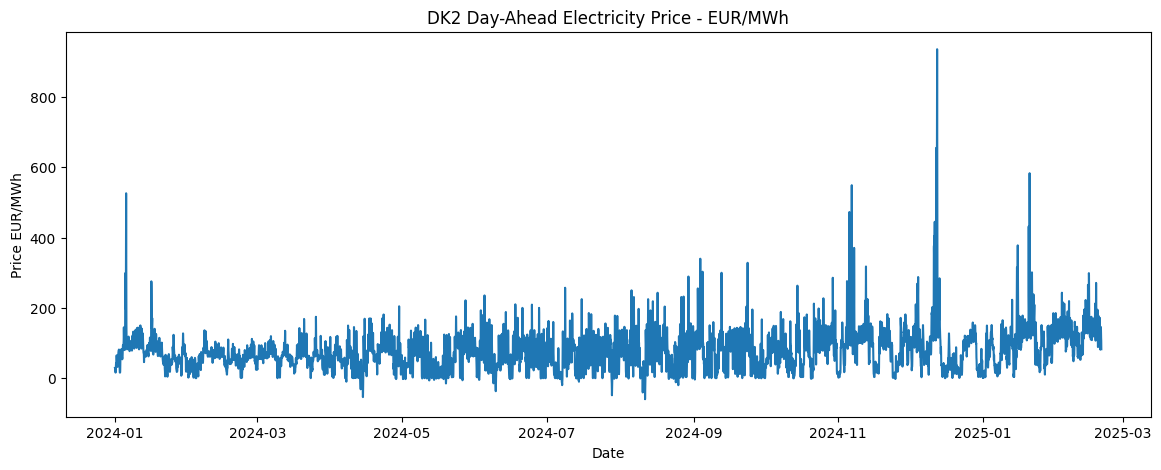

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df["HourDK"], df["SpotPriceEUR"])
plt.title("DK2 Day-Ahead Electricity Price - EUR/MWh")
plt.xlabel("Date")
plt.ylabel("Price EUR/MWh")
plt.show()

In [7]:
df["hour"] = df["HourDK"].dt.hour
df["day_of_week"] = df["HourDK"].dt.dayofweek
df["month"] = df["HourDK"].dt.month

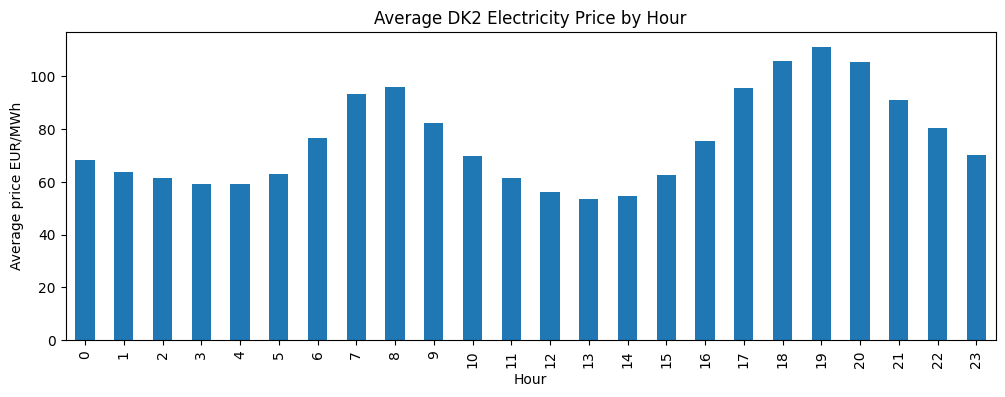

In [8]:
df.groupby("hour")["SpotPriceEUR"].mean().plot(kind="bar", figsize=(12, 4))
plt.title("Average DK2 Electricity Price by Hour")
plt.xlabel("Hour")
plt.ylabel("Average price EUR/MWh")
plt.show()

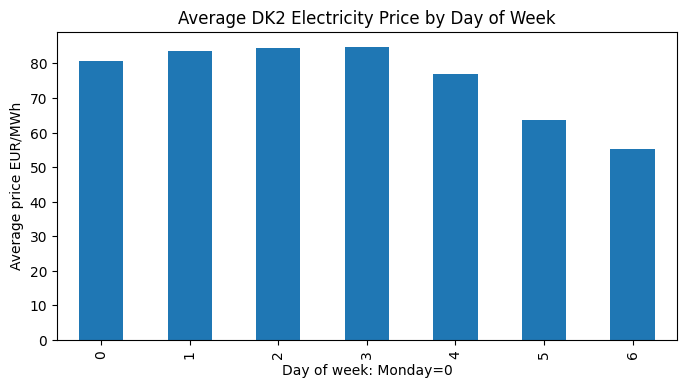

In [9]:
df.groupby("day_of_week")["SpotPriceEUR"].mean().plot(kind="bar", figsize=(8, 4))
plt.title("Average DK2 Electricity Price by Day of Week")
plt.xlabel("Day of week: Monday=0")
plt.ylabel("Average price EUR/MWh")
plt.show()